# 서버 유지보수 데이터 시각화 (11종) — *Fundamentals of Data Visualization* 원칙

Claus O. Wilke의 원칙을 반영합니다.

- **색은 데이터를 인코딩할 때만** 쓴다 (장식용 무지개·불필요한 채도 남용 금지).
- **동일 범주 → 동일 색**: `issue_category`, `check_type` 등은 노트북 전체에서 **같은 색 매핑**을 유지한다.
- **색각 이상 친화**: Okabe–Ito 팔레트(논문·교재에서 널리 쓰는 조합)로 범주를 구분한다.
- **강조는 절제**: 한 그래프에서 눈에 띄게 할 요소만 **vermillion(`#D55E00`)** 등으로 강조한다.
- **연속형·분포**: 단일 색조(청색 계열)의 농도·투명도로 표현한다.
- **Data-ink**: 기본적으로 상·우 spine 제거, 격자는 읽기에 필요한 축에만.

**데이터**: `dataset/정형/서버유지보수_보정데이터(0512).csv`

In [2]:
# ── 나눔고딕 폰트 설치 (최초 1회, 이후 주석 처리 가능) ──────────────
!sudo apt-get install -y -qq fonts-nanum
!fc-cache -fv
!rm ~/.cache/matplotlib -rf

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share

# Google Drive 연동

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# ── Seaborn ───────────────────────────────────────────────────────
# 통계 그래프·테마

"""
시각화 공통: 폰트, Wilke/Okabe-Ito 색 체계, 범주→색 고정 매핑
(이 셀은 이후 모든 차트에서 재사용하는 상수·함수·데이터 로드를 한 번에 둡니다.)
"""
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path

# ── 나눔고딕 폰트 설정 (matplotlib + seaborn 동시 적용) ───────────
def set_nanum_gothic():
    """
    설치된 NanumGothic 폰트 경로를 탐색해 matplotlib/seaborn 양쪽에 등록.
    Colab(Linux) 환경 기준; Windows는 Malgun Gothic으로 fallback.
    """
    if platform.system() == "Windows":
        font_name = "Malgun Gothic"
    else:
        # 설치된 폰트 중 NanumGothic 계열 탐색
        nanum_fonts = [
            f for f in fm.findSystemFonts(fontpaths=None, fontext="ttf")
            if "NanumGothic" in f and "Bold" not in f and "ExtraBold" not in f
        ]
        if nanum_fonts:
            # FontProperties로 등록 후 family 이름 추출
            prop = fm.FontProperties(fname=nanum_fonts[0])
            font_name = prop.get_name()
            fm.fontManager.addfont(nanum_fonts[0])  # 캐시에 명시적으로 추가
        else:
            print("NanumGothic 폰트를 찾을 수 없습니다. 위 설치 셀 주석을 해제하고 런타임을 재시작하세요.")
            font_name = "DejaVu Sans"

    # matplotlib 전역 설정
    plt.rcParams["font.family"] = font_name
    plt.rcParams["font.sans-serif"] = [font_name, "DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False  # 마이너스 부호 깨짐 방지

    # seaborn은 matplotlib rcParams를 그대로 참조하므로 추가 설정 불필요.
    # sns.set_theme의 font 인자로도 명시해 완전히 고정.
    return font_name

FONT_NAME = set_nanum_gothic()
print(f"적용 폰트: {FONT_NAME}")

# ── Okabe-Ito 팔레트 ──────────────────────────────────────────────
PALETTE_OI = [
    "#E69F00",  # 주황
    "#56B4E9",  # 하늘색
    "#009E73",  # 녹색
    "#F0E442",  # 노랑
    "#0072B2",  # 파랑
    "#D55E00",  # vermillion
    "#CC79A7",  # 자주
    "#000000",  # 검정
]
COLOR_SEQ          = "#0072B2"   # 연속형·분포: 단일 색조(파랑)
COLOR_NEUTRAL_BAR  = "#B0B0B0"   # 비교 막대 중 배경에 가까운 톤
COLOR_EMPHASIS     = "#D55E00"   # 한 요소만 강조할 때
COLOR_TEXT         = "#2E2E2E"

# seaborn 테마: font 인자에 탐색한 폰트명을 직접 전달 → rc 덮어쓰기 방지
sns.set_theme(
    style="ticks",
    context="notebook",
    font=FONT_NAME,          # ← matplotlib rcParams["font.family"]와 동기화
    rc={
        "font.family":        FONT_NAME,
        "font.sans-serif":    [FONT_NAME, "DejaVu Sans"],
        "axes.unicode_minus": False,
    },
)
sns.set_palette(PALETTE_OI)

# ── 경로 설정 (Google Colab + Drive) ─────────────────────────────
DATA_DIR = Path("/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset")
# ※ 이미지에서 확인한 파일명 그대로 사용
CSV_SOLDIER  = DATA_DIR / "장병데이터.csv"
CSV_SERVER   = DATA_DIR / "서버데이터.csv"
CSV_SUPPLIES = DATA_DIR / "군수품데이터.csv"

def load_csv(path: Path) -> pd.DataFrame:
    """UTF-8 → UTF-8-sig 순서로 인코딩 재시도."""
    try:
        return pd.read_csv(path, encoding="utf-8")
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding="utf-8-sig")

df_soldier  = load_csv(CSV_SOLDIER)
df_server   = load_csv(CSV_SERVER)
df_supplies = load_csv(CSV_SUPPLIES)

# check_date 컬럼이 있는 경우에만 파싱 (서버 데이터 기준)
for df, name in [(df_server, "서버"), (df_soldier, "장병"), (df_supplies, "군수품")]:
    if "check_date" in df.columns:
        df["check_date"] = pd.to_datetime(df["check_date"], errors="coerce")
        df["month"] = df["check_date"].dt.to_period("M").astype(str)
    print(f"{name} shape: {df.shape}")

SOURCE_LINE = "출처: 장병데이터.csv / 서버데이터.csv / 군수품데이터.csv"

# ── 유틸 함수 ────────────────────────────────────────────────────
def stable_cat_colors(values, palette=PALETTE_OI):
    """범주 이름 정렬 순으로 색을 고정 (차트 간 일관성)."""
    cats = sorted(pd.Series(values).dropna().unique())
    return {c: palette[i % len(palette)] for i, c in enumerate(cats)}


def spine_clean(ax, grid_x=False, grid_y=False):
    """Wilke식 Data-ink: 위·오른쪽 축선 제거, 필요한 축만 얇은 격자."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if grid_x:
        ax.grid(True, axis="x", linestyle="--", alpha=0.35, color="#CCCCCC")
    if grid_y:
        ax.grid(True, axis="y", linestyle="--", alpha=0.35, color="#CCCCCC")
    ax.set_axisbelow(True)


def add_footer(fig, caption=None, y_cap=0.085, y_src=0.02, tight_rect=None):
    """캡션 + 데이터 출처를 figure 하단에 고정 배치."""
    if tight_rect is None:
        tight_rect = [0, 0.18, 1, 0.95]
    fig.tight_layout(rect=tight_rect)
    if caption:
        fig.text(0.5, y_cap, caption, ha="center", fontsize=9, style="italic", color=COLOR_TEXT)
    fig.text(0.99, y_src, SOURCE_LINE, ha="right", fontsize=8, color="#666666")


# ── 색 매핑 (서버 데이터 기준, 필요 시 다른 df로 교체) ──────────
if "issue_category" in df_server.columns:
    COLOR_BY_ISSUE = stable_cat_colors(df_server["issue_category"])
if "check_type" in df_server.columns:
    COLOR_BY_CHECK = stable_cat_colors(df_server["check_type"])

df_server.head()

적용 폰트: NanumGothic
서버 shape: (11000, 16)
장병 shape: (11000, 19)
군수품 shape: (11000, 15)


,log_id,server_id,location,check_date,check_type,issue_detected,issue_category,cpu_usage,memory_usage,disk_usage,temp_abnormal_flag,uptime_days,auto_alert_triggered,fix_required,fix_duration_hours,month
0,CHK000001,SRV0001,17사단,2024-12-11 05:00:00,월간,0,디스크,21.1,30.8,24.0,1,137,1,1,1.20,2024-12
1,CHK000002,SRV0002,25사단,2024-12-10 06:00:00,일간,1,CPU과부하,11.6,18.2,16.1,0,169,1,0,4.67,2024-12
2,CHK000003,SRV0003,21사단,2024-08-07 02:00:00,일간,0,CPU과부하,41.0,27.9,20.1,1,269,1,1,4.12,2024-08
3,CHK000004,SRV0004,18사단,2024-10-02 20:00:00,일간,1,없음,36.1,24.0,23.1,0,164,1,0,5.43,2024-10
4,CHK000005,SRV0005,17사단,2024-08-07 19:00:00,주간,0,CPU과부하,20.8,34.7,28.3,0,233,1,1,2.87,2024-08


## 차트 1 — 수평 막대 (barh)

**종류**: 수평 막대.

**목적**: 이슈 유형별 건수 비교. Wilke식 **강조**: 대부분 **중립 회색 막대**, **최다 건수만** vermillion으로 끌어올려 메시지를 한 곳에 수렴 (색이 여러 의미로 쓰이지 않음).

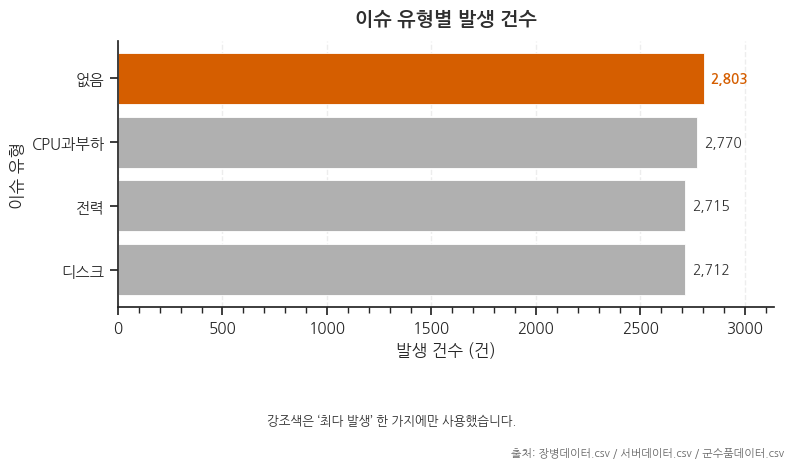

In [3]:
# -------------------------------------------------------------------------
# 1. 데이터 준비 및 강조 색상 설정
# -------------------------------------------------------------------------
# 이슈 유형별 건수를 집계하고, 가로 막대 그래프를 위해 오름차순 정렬
# (오름차순 정렬 시, 가장 큰 값이 그래프의 맨 위에 위치하게 됨)
issue_counts = df_server["issue_category"].value_counts().sort_values(ascending=True)
n = len(issue_counts)

# 마지막 막대(최다 건수)만 강조색을 적용하고 나머지는 중립색으로 설정
colors = [COLOR_NEUTRAL_BAR] * (n - 1) + [COLOR_EMPHASIS]

# -------------------------------------------------------------------------
# 2. 그래프 기본 생성 및 스타일링
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5)) # 그래프 크기 설정

# 가로 막대(barh) 생성: 흰색 테두리(edgecolor)를 추가하여 막대 간 경계 명확화
bars = ax.barh(issue_counts.index, issue_counts.values,
               color=colors, edgecolor="white", linewidth=0.6)

# 제목 및 축 레이블 설정 (폰트 크기, 굵기, 여백 조절)
ax.set_title("이슈 유형별 발생 건수", fontsize=14, fontweight="bold", color=COLOR_TEXT, pad=12)
ax.set_xlabel("발생 건수 (건)")
ax.set_ylabel("이슈 유형")

# -------------------------------------------------------------------------
# 3. 축 범위 및 눈금(Tick) 최적화
# -------------------------------------------------------------------------
xmax = issue_counts.max()
# 텍스트 라벨이 잘리지 않도록 X축 오른쪽 여백을 최대값의 12%만큼 추가 확보
ax.set_xlim(0, xmax * 1.12)

# 주 눈금은 500 단위, 보조 눈금은 100 단위로 세밀하게 설정
ax.xaxis.set_major_locator(mticker.MultipleLocator(500))
ax.xaxis.set_minor_locator(mticker.MultipleLocator(100))

# 테두리를 정리하고 세로 격자선(grid_x)만 활성화 (가독성 향상)
spine_clean(ax, grid_x=True)

# -------------------------------------------------------------------------
# 4. 막대 끝 데이터 레이블링 (Annotation)
# -------------------------------------------------------------------------
for i, bar in enumerate(bars):
    w = bar.get_width() # 막대의 너비(실제 데이터 값)

    ax.annotate(
        f"{int(w):,}",                  # 천 단위 콤마 포함한 숫자 텍스트
        xy=(w, bar.get_y() + bar.get_height() / 2), # 기준점: 막대의 오른쪽 끝 중앙
        xytext=(5, 0),                  # 기준점에서 오른쪽으로 5포인트 떨어진 위치
        textcoords="offset points",     # 포인트 단위의 상대 위치 지정
        ha="left",                      # 텍스트의 왼쪽 끝을 기준점에 맞춤
        va="center",                    # 텍스트의 수직 중앙 정렬
        fontsize=10,
        # 최다 발생 항목(마지막 루프)만 텍스트 색상과 굵기를 강조
        color=COLOR_EMPHASIS if i == n - 1 else COLOR_TEXT,
        fontweight="bold" if i == n - 1 else "normal",
    )

# -------------------------------------------------------------------------
# 5. 푸터 추가 및 출력
# -------------------------------------------------------------------------
add_footer(fig, "강조색은 ‘최다 발생’ 한 가지에만 사용했습니다.")
plt.show()

## 차트 2 — 수직 막대 (bar)

**종류**: 수직 막대.

**목적**: 점검 유형별 건수. **각 막대 색 = 점검 유형**을 나타내며, 이후 차트 6과 **동일한 `COLOR_BY_CHECK` 매핑**을 사용해 해석이 연속되도록 함.

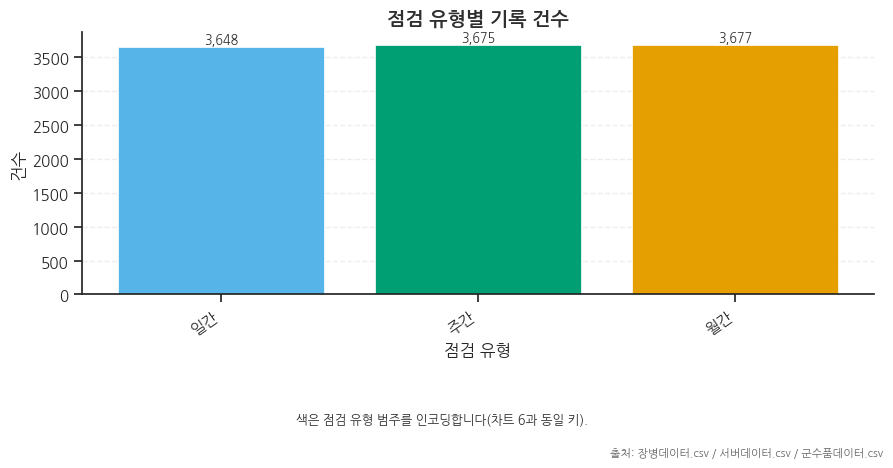

In [4]:
# -------------------------------------------------------------------------
# 1. 데이터 집계 및 범주별 색상 매핑
# -------------------------------------------------------------------------
# 점검 유형별 건수를 계산하고 시각적 균형을 위해 오름차순 정렬
ct = df_server["check_type"].value_counts().sort_values(ascending=True)

# 미리 정의된 전역 색상 사전(COLOR_BY_CHECK)에서 각 범주에 맞는 색상을 리스트로 추출
# 이를 통해 보고서 내의 다른 차트들과 동일한 범주-색상 관계를 유지 (시각적 일관성)
bar_colors = [COLOR_BY_CHECK[c] for c in ct.index]

# -------------------------------------------------------------------------
# 2. 그래프 생성 및 막대 배치
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(ct))  # 막대가 놓일 x축의 수치적 위치 (0, 1, 2, ...)

# 세로 막대 그래프 생성
ax.bar(x, ct.values, color=bar_colors, edgecolor="white", linewidth=0.5)

# -------------------------------------------------------------------------
# 3. 축 설정 및 라벨 가독성 최적화
# -------------------------------------------------------------------------
# x축 눈금 위치에 실제 범주 명칭(ct.index)을 표시
# rotation=35: 라벨이 길 경우 겹치지 않도록 35도 회전
# ha="right": 회전된 라벨의 끝부분(오른쪽)을 눈금 위치에 맞춤 (가독성 향상)
ax.set_xticks(x, ct.index, rotation=35, ha="right")

ax.set_title("점검 유형별 기록 건수", fontsize=14, fontweight="bold", color=COLOR_TEXT)
ax.set_ylabel("건수")
ax.set_xlabel("점검 유형")

# 불필요한 테두리를 제거하고 수평 격자선(grid_y)만 활성화하여 값 비교를 도움
spine_clean(ax, grid_y=True)

# -------------------------------------------------------------------------
# 4. 막대 상단 데이터 레이블링 (Value Labels)
# -------------------------------------------------------------------------
ymax = ct.max()
for i, v in enumerate(ct.values):
    # 각 막대(i)의 상단(v)에서 약간 위(ymax * 0.015) 지점에 텍스트 표시
    ax.text(
        i,
        v + ymax * 0.015,
        f"{int(v):,}",   # 천 단위 구분 콤마 적용
        ha="center",     # 막대 너비의 정중앙 정렬
        fontsize=9,
        color=COLOR_TEXT
    )

# -------------------------------------------------------------------------
# 5. 푸터 추가 및 출력
# -------------------------------------------------------------------------
# 범례 대신 색상의 의미를 설명하는 주석(Footer)을 추가
add_footer(fig, "색은 점검 유형 범주를 인코딩합니다(차트 6과 동일 키).")
plt.show()

## 차트 3 — 히스토그램 (histplot)

**종류**: 히스토그램.

**목적**: `cpu_usage` 분포. **단일 색조**(연한 채우기 + 진한 테두리)만 사용해 빈도라는 **하나의 변수**만 표현 (불필요한 색 분리 없음).

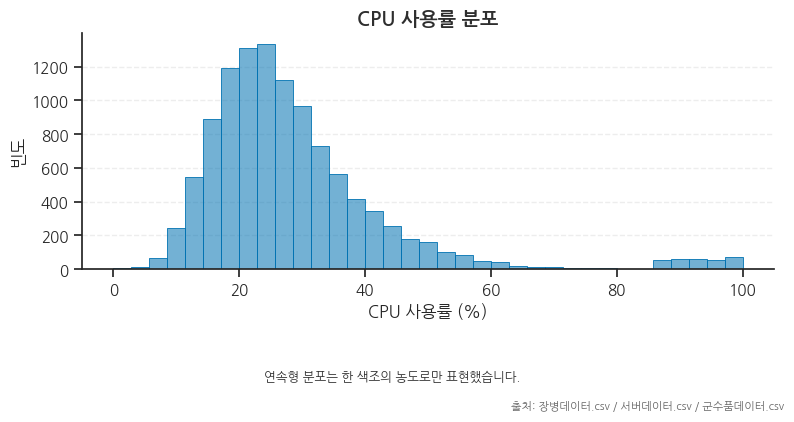

In [5]:
# -------------------------------------------------------------------------
# 1. 데이터 준비
# -------------------------------------------------------------------------
# CPU 사용률(%)의 분포를 본다. 연속형 한 변수이므로 색은 단일 색조(COLOR_SEQ)만 사용 (Wilke).

# -------------------------------------------------------------------------
# 2. 그래프 영역 및 히스토그램(histplot)
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4.5))  # figure 크기(가로×세로, inch)

sns.histplot(
    df_server,
    x="cpu_usage",  # 히스토그램의 가로축 변수(열 이름)
    bins=35,  # 구간 개수 — 크면 더 잘게 쪼개짐
    kde=False,  # 커널 밀도 곡선 비활성(막대만)
    color=COLOR_SEQ,  # 막대 면색
    edgecolor=COLOR_SEQ,  # 막대 테두리색(데이터 잉크 색 일치)
    linewidth=0.6,  # 막대 테두리 두께
    alpha=0.55,  # 투명도(겹침·밀도 시각적 완화)
    ax=ax,  # 그릴 Axes 객체
)

# -------------------------------------------------------------------------
# 3. 제목·축·격자(Data-ink)
# -------------------------------------------------------------------------
ax.set_title("CPU 사용률 분포", fontsize=14, fontweight="bold", color=COLOR_TEXT)  # 제목 글꼴
ax.set_xlabel("CPU 사용률 (%)")
ax.set_ylabel("빈도")  # 각 구간에 포함된 행 수
spine_clean(ax, grid_y=True)  # 상·우 spine 제거, 가로 격자만

# -------------------------------------------------------------------------
# 4. 푸터 및 출력
# -------------------------------------------------------------------------
add_footer(fig, "연속형 분포는 한 색조의 농도로만 표현했습니다.")
plt.show()



## 차트 4 — KDE (kdeplot)

**종류**: 커널 밀도 곡선.

**목적**: `memory_usage`의 매끄러운 밀도. 히스토그램과 **같은 청색 계열**을 유지해 ‘리소스 사용률’ 축 시각 언어를 통일.

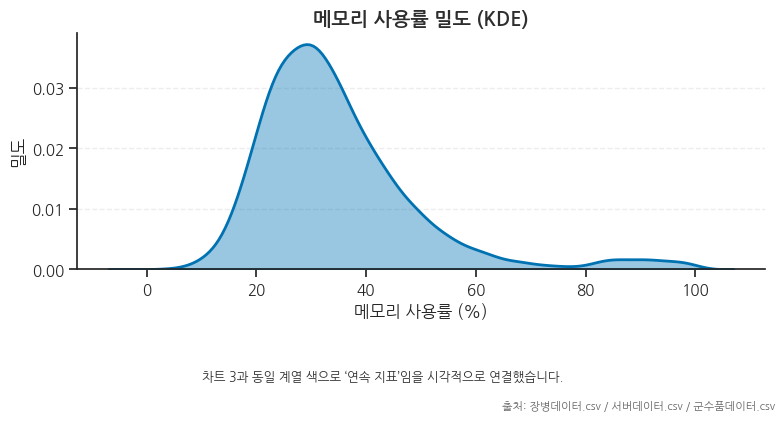

In [6]:
# -------------------------------------------------------------------------
# 1. 데이터 준비
# -------------------------------------------------------------------------
# 메모리 사용률의 부드러운 밀도 추정(KDE). 차트 3과 동일 색(COLOR_SEQ)으로 ‘연속 지표’임을 연결.

# -------------------------------------------------------------------------
# 2. 그래프 영역 및 KDE 곡선
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4.5))

sns.kdeplot(
    data=df_server,
    x="memory_usage",  # 밀도를 추정할 변수
    fill=True,  # 곡선 아래 영역 채움
    color=COLOR_SEQ,  # 선·채움 기본색
    linewidth=2,  # 곡선 두께
    alpha=0.4,  # 채움·곡선 투명도
    ax=ax,
)

# -------------------------------------------------------------------------
# 3. 제목·축·격자
# -------------------------------------------------------------------------
ax.set_title("메모리 사용률 밀도 (KDE)", fontsize=14, fontweight="bold", color=COLOR_TEXT)
ax.set_xlabel("메모리 사용률 (%)")
ax.set_ylabel("밀도")  # 적분하면 1이 되도록 스케일된 추정 밀도
spine_clean(ax, grid_y=True)

# -------------------------------------------------------------------------
# 4. 푸터 및 출력
# -------------------------------------------------------------------------
add_footer(fig, "차트 3과 동일 계열 색으로 ‘연속 지표’임을 시각적으로 연결했습니다.")
plt.show()



## 차트 5 — 박스플롯 (boxplot)

**종류**: 상자 수염.

**목적**: 이슈 유형별 `cpu_usage`. 막대/파이와 **같은 `COLOR_BY_ISSUE`**로 채색해 범주 색이 **데이터셋 전반에서 동일한 의미**를 갖게 함.

/tmp/ipykernel_3100/1217338416.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


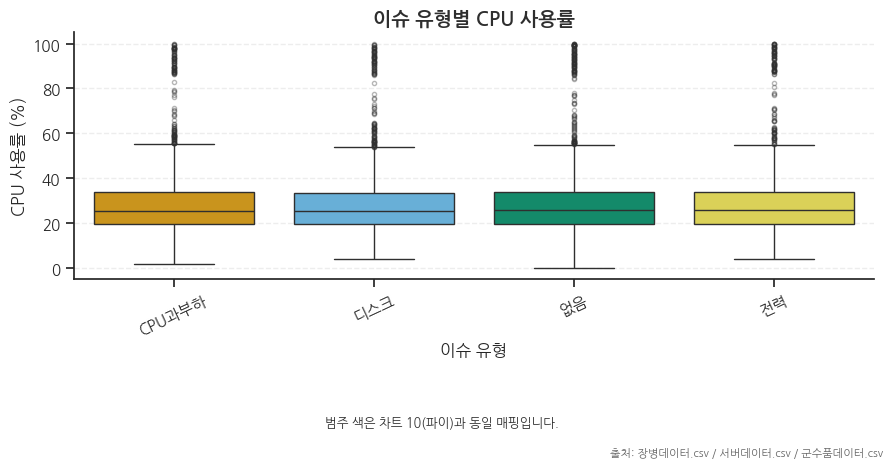

In [7]:
# -------------------------------------------------------------------------
# 1. 데이터 준비 및 범주 순서·색
# -------------------------------------------------------------------------
# 이슈 유형(범주)별 CPU 사용률 분포를 박스로 비교. x축 순서 고정 + 차트 10과 동일 COLOR_BY_ISSUE.

order = sorted(df_server["issue_category"].dropna().unique())  # 범주 알파벳(가나다) 정렬로 순서 고정
palette_issue = [COLOR_BY_ISSUE[c] for c in order]  # 박스마다 동일 범주=동일 색

# -------------------------------------------------------------------------
# 2. 그래프 영역 및 박스플롯
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(
    data=df_server,
    x="issue_category",  # 범주 축
    y="cpu_usage",  # 연속 축
    order=order,  # x축 범주 순서
    palette=palette_issue,  # 각 박스 색(범주 인코딩)
    linewidth=1,  # 박스·수염 선 두께
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.35},  # 이상치(outlier) 점 스타일
    ax=ax,
)

# -------------------------------------------------------------------------
# 3. 제목·축·눈금
# -------------------------------------------------------------------------
ax.set_title("이슈 유형별 CPU 사용률", fontsize=14, fontweight="bold", color=COLOR_TEXT)
ax.set_xlabel("이슈 유형")
ax.set_ylabel("CPU 사용률 (%)")
ax.tick_params(axis="x", rotation=25)  # 긴 라벨 겹침 완화(도)
spine_clean(ax, grid_y=True)

# -------------------------------------------------------------------------
# 4. 푸터 및 출력
# -------------------------------------------------------------------------
add_footer(fig, "범주 색은 차트 10(파이)과 동일 매핑입니다.", y_cap=0.08)
plt.show()



## 차트 6 — 바이올린 (violinplot)

**종류**: 바이올린.

**목적**: 점검 유형별 `disk_usage` 분포 형태. **차트 2와 동일한 `COLOR_BY_CHECK`**로 색을 맞춤 — 동일 범주가 다른 그래프에서 다른 색으로 보이는 혼란을 제거.

/tmp/ipykernel_3100/2709294049.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


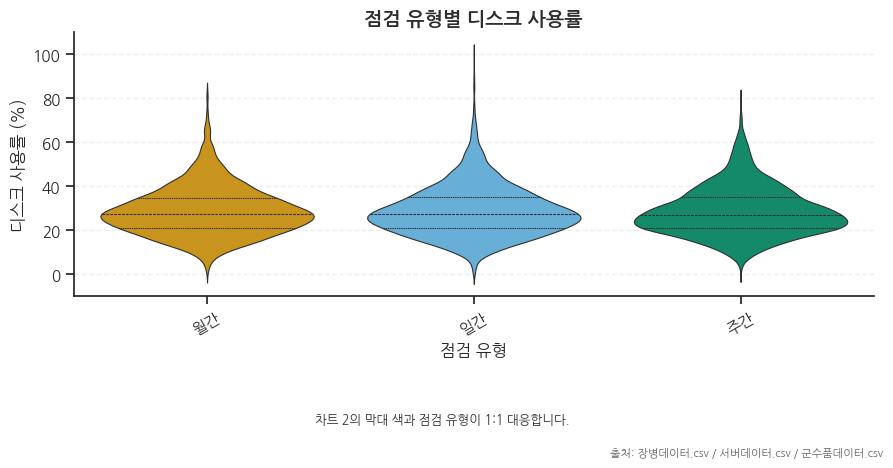

In [8]:
# -------------------------------------------------------------------------
# 1. 데이터 준비 및 범주 순서·색
# -------------------------------------------------------------------------
# 점검 유형별 디스크 사용률 분포(바이올린). 차트 2·6과 동일 COLOR_BY_CHECK.

order_chk = sorted(df_server["check_type"].dropna().unique())
pal_chk = [COLOR_BY_CHECK[c] for c in order_chk]

# -------------------------------------------------------------------------
# 2. 그래프 영역 및 바이올린
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))

sns.violinplot(
    data=df_server,
    x="check_type",
    y="disk_usage",
    order=order_chk,  # x축 범주 순서
    palette=pal_chk,  # 바이올린 채움색(범주)
    inner="quart",  # 내부에 사분위(박스 유사) 표시
    linewidth=0.8,  # 윤곽선 두께
    ax=ax,
)

# -------------------------------------------------------------------------
# 3. 제목·축·눈금
# -------------------------------------------------------------------------
ax.set_title("점검 유형별 디스크 사용률", fontsize=14, fontweight="bold", color=COLOR_TEXT)
ax.set_xlabel("점검 유형")
ax.set_ylabel("디스크 사용률 (%)")
ax.tick_params(axis="x", rotation=30)
spine_clean(ax, grid_y=True)

# -------------------------------------------------------------------------
# 4. 푸터 및 출력
# -------------------------------------------------------------------------
add_footer(fig, "차트 2의 막대 색과 점검 유형이 1:1 대응합니다.")
plt.show()



## 차트 7 — hexbin (2차원 밀도)

**종류**: 육각형 구간 집계(hexbin). **개별 점(산점도)을 찍지 않고** 격자 셀별 건수로 밀도를 표현합니다.

**목적**: CPU–메모리 결합 분포와 이슈 탐지 여부. **이진 분할 2패널**: 미탐지는 청색 계열(`Blues`), 탐지는 주황 계열(`Oranges`) — Okabe–Ito의 파랑·주황 의미와 맞춥니다.

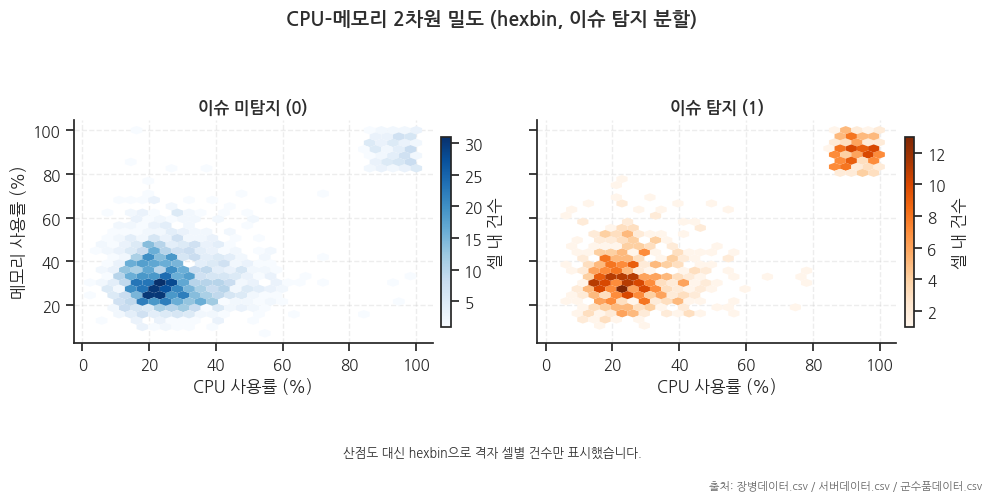

In [9]:
# -------------------------------------------------------------------------
# 1. 데이터 준비 (부분 표본·패널 정의)
# -------------------------------------------------------------------------
# 산점도 대신 hexbin으로 CPU–메모리 2차원 밀도 표시. 이슈 탐지 0/1로 좌우 분할 비교.
sample = df_server.sample(min(2500, len(df_server)), random_state=42)  # 재현 가능한 무작위 표본
panels = [
    (0, "이슈 미탐지 (0)", "Blues"),  # (코드값, 패널 제목, 연속 컬러맵 이름)
    (1, "이슈 탐지 (1)", "Oranges"),
]

# -------------------------------------------------------------------------
# 2. 서브플롯 레이아웃 (축 범위 공유)
# -------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4.8), sharex=True, sharey=True)  # 두 패널 동일 x·y 스케일

# -------------------------------------------------------------------------
# 3. 패널별 hexbin + 컬러바
# -------------------------------------------------------------------------
for ax, (code, title, cmap) in zip(axes, panels):
    sub = sample[sample["issue_detected"].astype(float) == code]  # 해당 이슈 플래그만
    if len(sub) < 2:
        ax.text(0.5, 0.5, "데이터 부족", ha="center", va="center", transform=ax.transAxes)  # 축 비율 좌표(0~1)
        ax.set_title(title)
        continue
    hb = ax.hexbin(
        sub["cpu_usage"],
        sub["memory_usage"],
        gridsize=28,  # 육각 격자 해상도(가로 방향 셀 수에 비례)
        cmap=cmap,  # 셀 값(건수)을 색으로 매핑
        mincnt=1,  # 이 값 미만인 셀은 그리지 않음
        linewidths=0,  # 육각형 경계선 제거
    )
    cb = fig.colorbar(hb, ax=ax, shrink=0.85, pad=0.02)  # shrink: 컬러바 높이 비율, pad: 축과 간격
    cb.set_label("셀 내 건수")
    ax.set_title(title, fontsize=12, fontweight="bold", color=COLOR_TEXT)
    spine_clean(ax, grid_y=True, grid_x=True)

# -------------------------------------------------------------------------
# 4. 공통 축 라벨·전체 제목·여백
# -------------------------------------------------------------------------
axes[0].set_ylabel("메모리 사용률 (%)")
for ax in axes:
    ax.set_xlabel("CPU 사용률 (%)")
fig.suptitle("CPU–메모리 2차원 밀도 (hexbin, 이슈 탐지 분할)", fontsize=14, fontweight="bold", color=COLOR_TEXT, y=1.02)  # figure 상단 여백(y>1이면 위로)
plt.tight_layout()

# -------------------------------------------------------------------------
# 5. 푸터 및 출력
# -------------------------------------------------------------------------
add_footer(fig, "산점도 대신 hexbin으로 격자 셀별 건수만 표시했습니다.", y_cap=0.09)
plt.show()



## 차트 8 — 선 그래프 (lineplot)

**종류**: 시계열 선 그래프.

**목적**: 월별 건수 추이. **단일 시계열**이므로 색 하나(`COLOR_SEQ`)만 사용 — 범주가 아닌데 색을 나누지 않음.

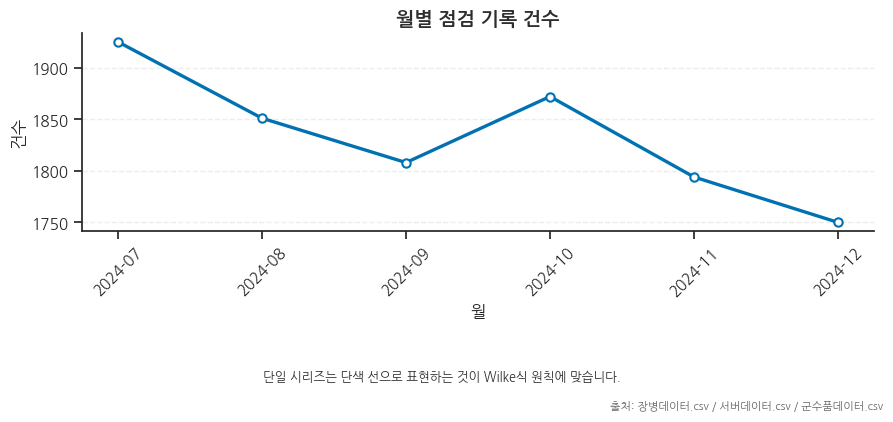

In [10]:
# -------------------------------------------------------------------------
# 1. 데이터 집계 (월별 건수)
# -------------------------------------------------------------------------
# month 열로 그룹화해 점검 기록 건수 시계열을 만든다.
monthly = df_server.groupby("month", as_index=False).size()
monthly = monthly.rename(columns={"size": "n"})  # 건수 열 이름을 n으로

# -------------------------------------------------------------------------
# 2. 선 그래프(line plot)
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(
    monthly["month"],  # x: 범주형 월 문자열(순서는 데이터프레임 행 순서)
    monthly["n"],  # y: 해당 월 건수
    color=COLOR_SEQ,  # 단일 시리즈 → 단색 선
    linewidth=2.4,  # 선 두께
    marker="o",  # 각 점 마커 모양
    markersize=6,  # 마커 크기
    markerfacecolor="white",  # 마커 내부는 비움(윤곽 강조)
    markeredgewidth=1.5,  # 마커 테두리 두께
    markeredgecolor=COLOR_SEQ,  # 마커 테두리 = 선 색
)

# -------------------------------------------------------------------------
# 3. 제목·축·눈금·격자
# -------------------------------------------------------------------------
ax.set_title("월별 점검 기록 건수", fontsize=14, fontweight="bold", color=COLOR_TEXT)
ax.set_xlabel("월")
ax.set_ylabel("건수")
ax.tick_params(axis="x", rotation=45)  # 월 라벨 기울임
spine_clean(ax, grid_y=True)

# -------------------------------------------------------------------------
# 4. 푸터 및 출력
# -------------------------------------------------------------------------
add_footer(fig, "단일 시리즈는 단색 선으로 표현하는 것이 Wilke식 원칙에 맞습니다.")
plt.show()



## 차트 9 — 히트맵 (heatmap)

**종류**: 상관행렬 히트맵.

**목적**: 수치 변수 간 선형 상관. **무지개 대신** `vlag`(중심 0, 파랑–적색 계열이지만 색각 고려된 seaborn diverging)으로 **크기와 부호**를 동시에 읽게 함.

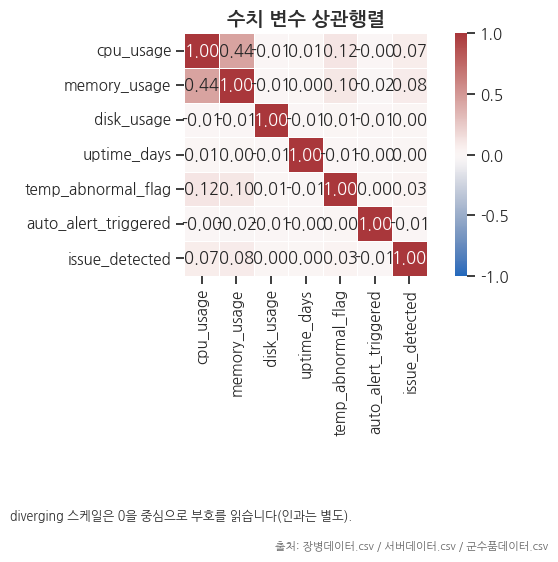

In [11]:
# -------------------------------------------------------------------------
# 1. 변수 선택 및 상관행렬 계산
# -------------------------------------------------------------------------
# 피어슨 상관계수 행렬. 발산(diverging) 컬러맵으로 0을 중심으로 읽는다(인과는 별도 검증 필요).
num_cols = [c for c in ["cpu_usage", "memory_usage", "disk_usage", "uptime_days", "temp_abnormal_flag", "auto_alert_triggered", "issue_detected"] if c in df_server.columns]
corr = df_server[num_cols].corr(numeric_only=True)  # 비수치 열 제외, 피어슨 기본
cmap_div = sns.color_palette("vlag", as_cmap=True)  # matplotlib Colormap 객체

# -------------------------------------------------------------------------
# 2. 히트맵
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.5, 6))

sns.heatmap(
    corr,  # 행·열이 변수인 정사각 행렬
    annot=True,  # 셀 안에 숫자 표시
    fmt=".2f",  # 소수 둘째 자리까지
    cmap=cmap_div,  # 음·양을 색 대비로
    center=0,  # 0에 중립색 매핑
    square=True,  # 셀을 정사각형에 가깝게
    linewidths=0.6,  # 셀 사이 흰 간격 두께
    linecolor="white",
    vmin=-1,  # 색 스케일 하한(상관계수 범위)
    vmax=1,  # 색 스케일 상한
    ax=ax,
)

# -------------------------------------------------------------------------
# 3. 제목·푸터
# -------------------------------------------------------------------------
ax.set_title("수치 변수 상관행렬", fontsize=14, fontweight="bold", color=COLOR_TEXT)
add_footer(fig, "diverging 스케일은 0을 중심으로 부호를 읽습니다(인과는 별도).", y_cap=0.07)
plt.show()



## 차트 10 — 파이 / 도넛 (pie)

**종류**: 구성비 파이(도넛).

**목적**: 이슈 유형 비율. **차트 5와 동일한 `COLOR_BY_ISSUE`**로 조각을 칠해 ‘같은 범주 = 같은 색’ 원칙을 유지.

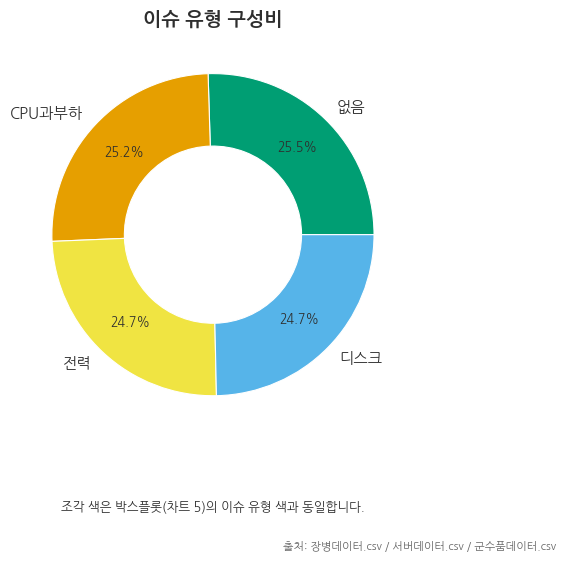

In [12]:
# -------------------------------------------------------------------------
# 1. 데이터 준비 및 색 목록
# -------------------------------------------------------------------------
# 이슈 유형 구성비(도넛). 조각 색은 차트 5와 동일 COLOR_BY_ISSUE.
vc = df_server["issue_category"].value_counts()
pie_colors = [COLOR_BY_ISSUE[c] for c in vc.index]

# -------------------------------------------------------------------------
# 2. 파이/도넛 그리기
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 6))

wedges, texts, autotexts = ax.pie(
    vc.values,  # 각 조각의 크기(건수)
    labels=vc.index,  # 범주 라벨
    autopct=lambda p: f"{p:.1f}%",  # 조각별 전체 대비 비율 문자열
    colors=pie_colors,
    pctdistance=0.75,  # 비율 텍스트가 놓일 반지름 비율(1=원 둘레)
    wedgeprops=dict(width=0.45, edgecolor="white", linewidth=0.8),  # width: 도넛 두께, edge: 조각 사이 구분
    textprops={"color": COLOR_TEXT},  # 바깥 범주 라벨 글자색
)

# -------------------------------------------------------------------------
# 3. 제목·비율 텍스트 스타일
# -------------------------------------------------------------------------
ax.set_title("이슈 유형 구성비", fontsize=14, fontweight="bold", color=COLOR_TEXT)
for t in autotexts:
    t.set_fontsize(9)  # 조각 안 비율 글자 크기
    t.set_color(COLOR_TEXT)

# -------------------------------------------------------------------------
# 4. 푸터 및 출력
# -------------------------------------------------------------------------
add_footer(fig, "조각 색은 박스플롯(차트 5)의 이슈 유형 색과 동일합니다.")
plt.show()



## 차트 11 — 워터폴 (waterfall)

**종류**: 워터폴(누적 변동).

**목적**: 월별 **`fix_duration_hours` 합계의 전월 대비 증감(Δ)** 을 본다. 첫 막대는 **첫 달 합계(기준)**, 중간은 **각 달의 전월比**(전월보다 늘면 녹색, 줄면 빨강), 마지막은 **마지막 달 합계**(누적이 아니라 “그 달 수준”). 이렇게 하면 월마다 오르내림이 드러난다. (월이 2개 미만이면 생략.)

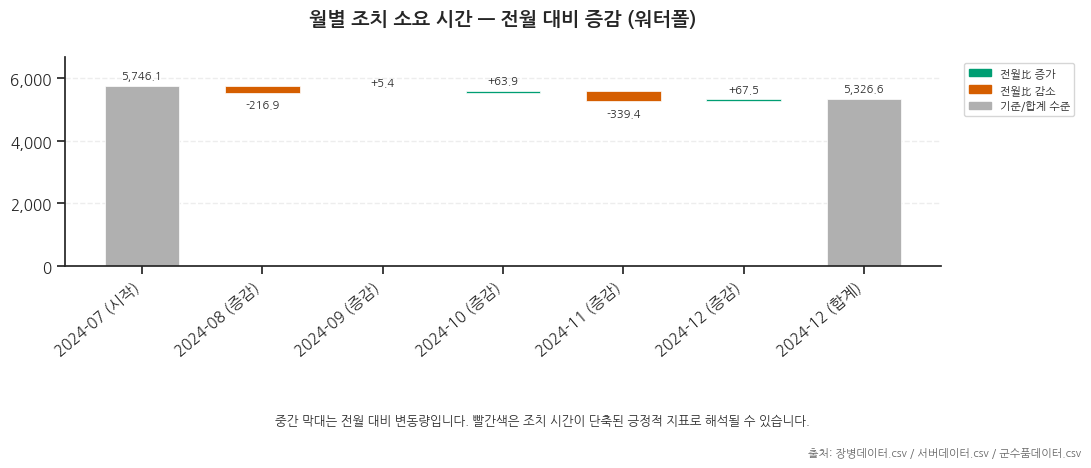

In [13]:
# -------------------------------------------------------------------------
# 0. 보조 라이브러리 임포트
# -------------------------------------------------------------------------
import matplotlib.patches as mpatches # 범례(Legend)용 커스텀 도형 생성

# -------------------------------------------------------------------------
# 1. 상수 설정 및 워터폴 막대 계산 함수
# -------------------------------------------------------------------------
# 월별 조치시간 합계 계산 (시계열 순서 보장)
monthly_fix = df_server.groupby("month", sort=True)["fix_duration_hours"].sum().sort_index()

COLOR_WF_UP = "#009E73"    # 증가 시 색상 (녹색)
COLOR_WF_DOWN = "#D55E00"  # 감소 시 색상 (주황/빨강)
COLOR_WF_TOTAL = COLOR_NEUTRAL_BAR # 시작 및 최종 합계 막대 색상

def build_waterfall_bars(values):
    """
    각 막대의 시작 높이(bottoms), 실제 높이(heights), 색상을 계산합니다.
    워터폴의 핵심인 '공중에 떠 있는 막대' 효과를 위해 bottom 값을 동적으로 조절합니다.
    """
    bottoms, heights, colors = [], [], []

    # 첫 번째 막대: 시작 수준 (바닥에서 시작)
    bottoms.append(0)
    heights.append(values[0])
    colors.append(COLOR_WF_TOTAL)

    running = values[0] # 누적 높이 추적

    # 중간 증감 막대 처리
    for i in range(1, len(values) - 1):
        delta = values[i]
        if delta >= 0:
            bottoms.append(running)  # 증가: 현재 누적 지점에서 위로 쌓음
            heights.append(delta)
            colors.append(COLOR_WF_UP)
            running += delta
        else:
            running += delta         # 감소: 누적치를 먼저 줄인 후
            bottoms.append(running)  # 감소한 지점을 바닥으로 설정 (위에서 아래로 내려오는 효과)
            heights.append(-delta)   # 높이는 양수로 변환
            colors.append(COLOR_WF_DOWN)

    # 마지막 막대: 최종 결과 수준 (다시 바닥 0에서 시작)
    bottoms.append(0)
    heights.append(values[-1])
    colors.append(COLOR_WF_TOTAL)

    return bottoms, heights, colors

# -------------------------------------------------------------------------
# 2. 데이터 유효성 검사 및 변수 구성
# -------------------------------------------------------------------------
if len(monthly_fix) < 2:
    print("데이터가 부족하여 워터폴 차트를 생성할 수 없습니다.")
else:
    mvals = monthly_fix.values.astype(float)
    months = list(monthly_fix.index)

    # 전월 대비 증감분(Delta) 계산
    deltas = [mvals[j] - mvals[j - 1] for j in range(1, len(mvals))]

    # 라벨 및 값 시퀀스 구성: [첫 달 값, 증감1, 증감2, ..., 최종 달 값]
    labels_wf = [f"{months[0]} (시작)"] + [f"{m} (증감)" for m in months[1:]] + [f"{months[-1]} (합계)"]
    wf_values = [mvals[0]] + deltas + [mvals[-1]]

    # -------------------------------------------------------------------------
    # 3. 그래프 생성 및 디자인 (Axes & Spines)
    # -------------------------------------------------------------------------
    bottoms, heights, bar_colors = build_waterfall_bars(wf_values)
    x = np.arange(len(labels_wf))

    fig, ax = plt.subplots(figsize=(11, 5))
    # bar 함수의 'bottom' 파라미터를 사용하여 워터폴 효과 구현
    bars = ax.bar(x, heights, 0.62, bottom=bottoms, color=bar_colors, edgecolor="white", linewidth=0.5)

    ax.set_title("월별 조치 소요 시간 — 전월 대비 증감 (워터폴)", fontsize=14, fontweight="bold", pad=24)
    ax.set_xticks(x)
    ax.set_xticklabels(labels_wf, rotation=40, ha="right")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}")) # 천 단위 콤마

    # Y축 범위 최적화 (여유 공간 16% 확보)
    y_top = max(b + h for b, h in zip(bottoms, heights)) * 1.16
    ax.set_ylim(0, y_top)
    spine_clean(ax, grid_y=True)

    # -------------------------------------------------------------------------
    # 4. 수치 주석 (Annotation) - 증감 방향에 따라 위치 조정
    # -------------------------------------------------------------------------
    for i, bar in enumerate(bars):
        b, h = bottoms[i], heights[i]
        if i == 0 or i == len(bars) - 1: # 시작/종합 막대: 상단에 값 표시
            ax.annotate(f"{b+h:,.1f}", xy=(bar.get_x() + bar.get_width()/2, b+h),
                        xytext=(0, 4), textcoords="offset points", ha="center", va="bottom", fontsize=8)
        else: # 증감 막대
            delta = wf_values[i]
            txt = f"{delta:+,.1f}" # 부호 포함 포맷
            if delta >= 0: # 증가: 막대 위쪽
                ax.annotate(txt, xy=(bar.get_x() + bar.get_width()/2, b+h),
                            xytext=(0, 4), textcoords="offset points", ha="center", va="bottom", fontsize=8)
            else: # 감소: 막대 아래쪽
                ax.annotate(txt, xy=(bar.get_x() + bar.get_width()/2, b),
                            xytext=(0, -4), textcoords="offset points", ha="center", va="top", fontsize=8)

    # -------------------------------------------------------------------------
    # 5. 범례(Legend) 및 푸터 설정
    # -------------------------------------------------------------------------
    legend_handles = [
        mpatches.Patch(color=COLOR_WF_UP, label="전월比 증가"),
        mpatches.Patch(color=COLOR_WF_DOWN, label="전월比 감소"),
        mpatches.Patch(color=COLOR_WF_TOTAL, label="기준/합계 수준")
    ]
    ax.legend(handles=legend_handles, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, frameon=True)

    add_footer(fig, "중간 막대는 전월 대비 변동량입니다. 빨간색은 조치 시간이 단축된 긍정적 지표로 해석될 수 있습니다.")
    plt.show()

## 탐색 — 군수품자동청구: `requested_quantity` × `avg_daily_usage` 산점도

청구 수량(건수)과 일평균 사용량의 관계를 **산점도** 한 장으로 확인합니다. 점이 많으면 **부분 샘플**로 겹침을 줄입니다. 안내 문구는 **그래프 안 상단**에 두어 하단 여백을 줄였습니다.

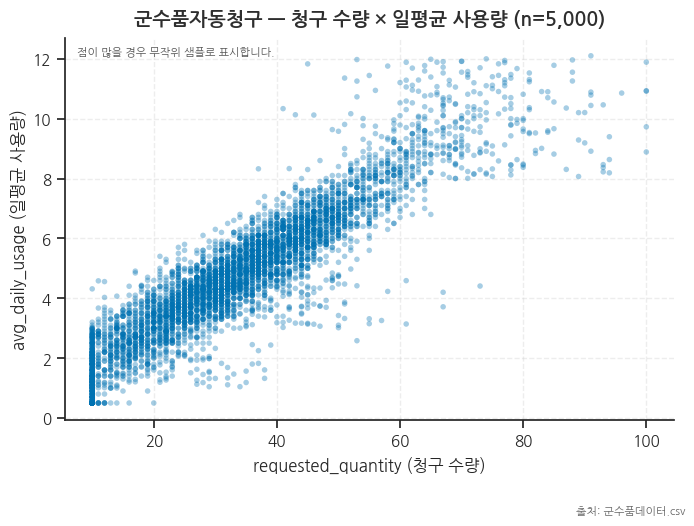

In [19]:
# -------------------------------------------------------------------------
# 1. 외부 CSV 로드 및 인코딩 예외 처리
# -------------------------------------------------------------------------
CSV_SUPPLY = DATA_DIR / "군수품데이터.csv"

try:
    df_supply = pd.read_csv(CSV_SUPPLY, encoding="utf-8")
except UnicodeDecodeError:
    df_supply = pd.read_csv(CSV_SUPPLY, encoding="utf-8-sig")

# -------------------------------------------------------------------------
# 2. 산점도용 데이터 전처리 및 샘플링 (Overplotting 방지)
# -------------------------------------------------------------------------
plot_df = df_supply[["requested_quantity", "avg_daily_usage"]].dropna()

n_plot = min(5000, len(plot_df))
if n_plot < len(plot_df):
    plot_df = plot_df.sample(n=n_plot, random_state=42)

# -------------------------------------------------------------------------
# 3. 산점도 구성 및 스타일링
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5.5))

ax.scatter(
    plot_df["requested_quantity"],
    plot_df["avg_daily_usage"],
    alpha=0.35,
    s=16,
    c=COLOR_SEQ,
    edgecolors="none",
)

ax.set_xlabel("requested_quantity (청구 수량)", labelpad=6)
ax.set_ylabel("avg_daily_usage (일평균 사용량)", labelpad=4)
ax.set_title(
    f"군수품자동청구 — 청구 수량 × 일평균 사용량 (n={len(plot_df):,})",
    fontsize=14, fontweight="bold", color=COLOR_TEXT, pad=10,
)

spine_clean(ax, grid_y=True, grid_x=True)

# -------------------------------------------------------------------------
# 4. 안내 문구, 레이아웃 및 메타데이터(출처) 표기
# -------------------------------------------------------------------------
ax.text(
    0.02, 0.98, "점이 많을 경우 무작위 샘플로 표시합니다.",
    transform=ax.transAxes,
    va="top", ha="left", fontsize=8, style="italic", color="#555555",
)

plt.tight_layout(rect=[0, 0.06, 1, 0.97])

fig.text(
    0.99, 0.02, "출처: 군수품데이터.csv",
    ha="right", fontsize=8, color="#666666",
)

plt.show()

## Multiple plot — 시계열 **2×6** 산점도 (`requested_quantity` × `avg_daily_usage`)

**군수품자동청구** 기간 2024-01 ~ 2024-06 (6개월)을 **전반(1~15일)** / 후반(16일~말일)으로 나누면 **2행×6열 = 12패널**이 됩니다.

| 행 | 구간 | 내용 |
|----|------|------|
| 위 6칸 | 각 달 **1~15일** | 산점도 |
| 아래 6칸 | 각 달 **16일~말일** | 동일 |

점 색은 **`inferno`**이며, **`requested_quantity`의 색 스케일은 0~100으로 고정**합니다. 패널당 점이 많으면 **무작위로 최대 `max_n`개**만 표시합니다. **colorbar**는 오른쪽 전용 열(두 행 통합). *(별도 선그래프 없음.)*


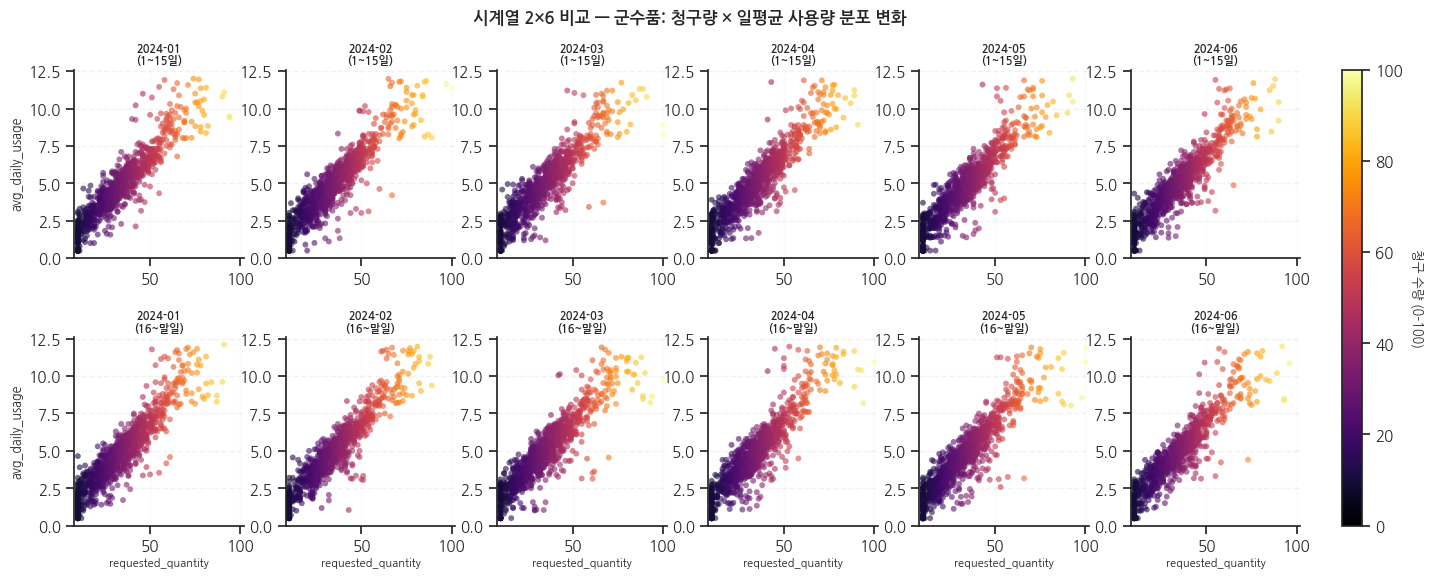

In [20]:
# -------------------------------------------------------------------------
# 0. 보조 라이브러리 임포트 (컬러바 및 정교한 격자 배치용)
# -------------------------------------------------------------------------
from matplotlib.colors import Normalize      # 데이터 값을 색상 범위(0~1)로 매핑
from matplotlib.cm import ScalarMappable     # 단독 컬러바 생성을 위한 매핑 객체
from matplotlib import gridspec              # 복잡한 레이아웃(비대칭 격자) 설계용

# -------------------------------------------------------------------------
# 1. 데이터 로드 및 시공간 파생 변수 생성
# -------------------------------------------------------------------------
# (파일 로드 예시, 사용 환경에 맞게 적절히 파일명/경로 수정)
import pandas as pd
import numpy as np

# 예시: csv파일에서 데이터 읽기

# -------------------------------------------------------------------------
# 1. 외부 CSV 로드 및 인코딩 예외 처리
# -------------------------------------------------------------------------
CSV_SUPPLY = DATA_DIR / "군수품데이터.csv"

try:
    df_supply = pd.read_csv(CSV_SUPPLY, encoding="utf-8")
except UnicodeDecodeError:
    df_supply = pd.read_csv(CSV_SUPPLY, encoding="utf-8-sig")

df_sup = df_supply.copy()
df_sup["_d"] = pd.to_datetime(df_sup["request_date"])  # 날짜형 변환
df_sup["_m"] = df_sup["_d"].dt.to_period("M")          # 연-월 단위 추출
df_sup["_first_half"] = df_sup["_d"].dt.day <= 15      # 15일 기준 상/하반월 구분 플래그

# 고유한 월(Month) 리스트 추출 및 정렬 (가로축 배치용)
sup_m = sorted(df_sup["_m"].dropna().unique())

# 모든 패널에서 동일한 스케일을 유지하기 위해 전역 최소/최대값 계산 (데이터 비교의 핵심)
x_all = df_sup["requested_quantity"].to_numpy(dtype=float)
y_all = df_sup["avg_daily_usage"].to_numpy(dtype=float)
xlim = (np.nanmin(x_all) - 2, np.nanmax(x_all) + 2)
ylim = (np.nanmin(y_all) - 0.5, np.nanmax(y_all) + 0.5)

# 컬러맵 설정: 'inferno' (검정-보라-오렌지-노랑 순의 시인성 좋은 연속 색상)
CMAP_SEQ = "inferno"
norm_rq = Normalize(vmin=0, vmax=100) # 모든 그래프의 색상 기준을 0~100으로 고정

max_n = 5000 # 패널당 최대 점 개수 제한 (성능 및 시각적 밀도 최적화)

# -------------------------------------------------------------------------
# 2. GridSpec 레이아웃 설계 (2행 7열)
# -------------------------------------------------------------------------
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(14, 6.0))
gs = gridspec.GridSpec(
    2, 7, figure=fig,
    width_ratios=[1, 1, 1, 1, 1, 1, 0.12], # 마지막 7번째 열은 컬러바 전용으로 좁게 설정
    height_ratios=[1, 1],
    hspace=0.42, wspace=0.28,              # 상하/좌우 간격 조정
    left=0.06, right=0.98, top=0.88, bottom=0.12
)

# 서브플롯 객체들을 담을 배열 생성
axes = np.empty((2, 6), dtype=object)
for r in range(2):
    for c in range(6):
        axes[r, c] = fig.add_subplot(gs[r, c])

# 오른쪽 끝 7번째 열의 1~2행 전체를 병합하여 컬러바 축(cax) 생성
cax = fig.add_subplot(gs[0:2, 6])

# spine_clean 함수 정의 (기존 내장 또는 직접 구현 필요)
# - 예시: 테두리 제거 및 그리드 추가
def spine_clean(ax, grid_y=True, grid_x=True):
    for loc in ['top','right']:
        ax.spines[loc].set_visible(False)
    if grid_y:
        ax.yaxis.grid(True, which='major', linestyle="--", alpha=0.25)
    if grid_x:
        ax.xaxis.grid(True, which='major', linestyle="--", alpha=0.13)

# -------------------------------------------------------------------------
# 3. 데이터 매핑 및 시각화 (상반월 & 하반월 루프)
# -------------------------------------------------------------------------
# 상반월(Row 0)과 하반월(Row 1) 데이터를 각각의 서브플롯에 그림
for row_idx, is_first in enumerate([True, False]):
    for col_idx, mo in enumerate(sup_m):
        ax = axes[row_idx, col_idx]

        # 해당 월 및 상/하반월 조건에 맞는 데이터 필터링
        condition = (df_sup["_m"] == mo) & (df_sup["_first_half"] == is_first)
        sub = df_sup.loc[condition, ["requested_quantity", "avg_daily_usage"]].dropna()

        # 과도한 점 겹침 방지를 위한 샘플링
        if len(sub) > max_n:
            sub = sub.sample(n=max_n, random_state=42, ignore_index=True)

        # 산점도 생성 (색상 'c'에 청구 수량을 매핑하여 값의 크기를 시각화)
        ax.scatter(
            sub["requested_quantity"], sub["avg_daily_usage"],
            c=sub["requested_quantity"], cmap=CMAP_SEQ, norm=norm_rq,
            alpha=0.6, s=18, edgecolors="none"
        )

        # 전역 범위를 적용하여 패널 간 비교가 가능하게 함
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)

        # 제목 및 테두리 정리
        period_txt = "1~15일" if is_first else "16~말일"
        ax.set_title(f"{mo}\n({period_txt})", fontsize=8, fontweight="bold", pad=4)
        spine_clean(ax, grid_y=True, grid_x=True)

        # 하단 행에만 X축 레이블 표시
        if row_idx == 1:
            ax.set_xlabel("requested_quantity", fontsize=8, labelpad=3)

# 첫 번째 열에만 Y축 레이블 표시 (중복 제거)
axes[0, 0].set_ylabel("avg_daily_usage", fontsize=9, labelpad=4)
axes[1, 0].set_ylabel("avg_daily_usage", fontsize=9, labelpad=4)

# -------------------------------------------------------------------------
# 4. 공통 컬러바(Colorbar) 및 전체 제목
# -------------------------------------------------------------------------
# 모든 서브플롯이 공유하는 색상 기준(norm_rq)을 컬러바에 적용
mappable = ScalarMappable(cmap=CMAP_SEQ, norm=norm_rq)
mappable.set_array([]) # 실제 데이터 연동 없이 스케일만 전달
cbar = fig.colorbar(mappable, cax=cax)
cbar.set_label("청구 수량 (0–100)", rotation=270, labelpad=14, fontsize=9)

# 전체 중앙 제목 설정
fig.suptitle(
    "시계열 2×6 비교 — 군수품: 청구량 × 일평균 사용량 분포 변화",
    fontsize=12, fontweight="bold", y=0.98
)

plt.show()

# Streamgraph

## 군수품자동청구 — **Streamgraph** & **순위(Bump) 차트**

### 의미 있게 볼 수 있는 변수

| 변수 | 이유 |
|------|------|
| **`category` (품목군)** | 사무·위생·의복·의료·식량 등 **5개 범주**로 청구 건수 비중이 어떻게 이동하는지 해석하기 좋음. 색은 **Okabe–Ito로 범주 고정**. |
| **`item_name` (세부 품목)** | 20개로 세분화되어 동일 그림에 넣으면 밴드·선이 과밀해짐 → **본 차트는 `category` 중심**으로 두고, 품목은 별도 막대/테이블로 보는 것을 권장. |
| **시계열 축 (주 단위)** | 데이터 기간이 **약 6개월**이라 **월만** 쓰면 점이 6개뿐 → **주(`W`) 단위 집계**로 포인트를 늘려 **비중·순위 변화**를 읽기 쉽게 함. |

- **위 차트(Streamgraph)**: 주별로 범주별 건수를 쌓되, `baseline='wiggle'`로 **중심 기준 흐름**을 표현 (연속 비중의 시계열).
- **아래 차트(Bump)**: 같은 주에서 건수 기준 **순위(1=최다)**를 범주별 선으로 연결해 **상대 순위 변화**를 강조.
- 세로 음영: **월 경계**를 표시해 분기·월 단위 맥락을 볼 수 있게 함.


/tmp/ipykernel_3100/1521992019.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.80, 1])  # 우측 범례 공간 확보


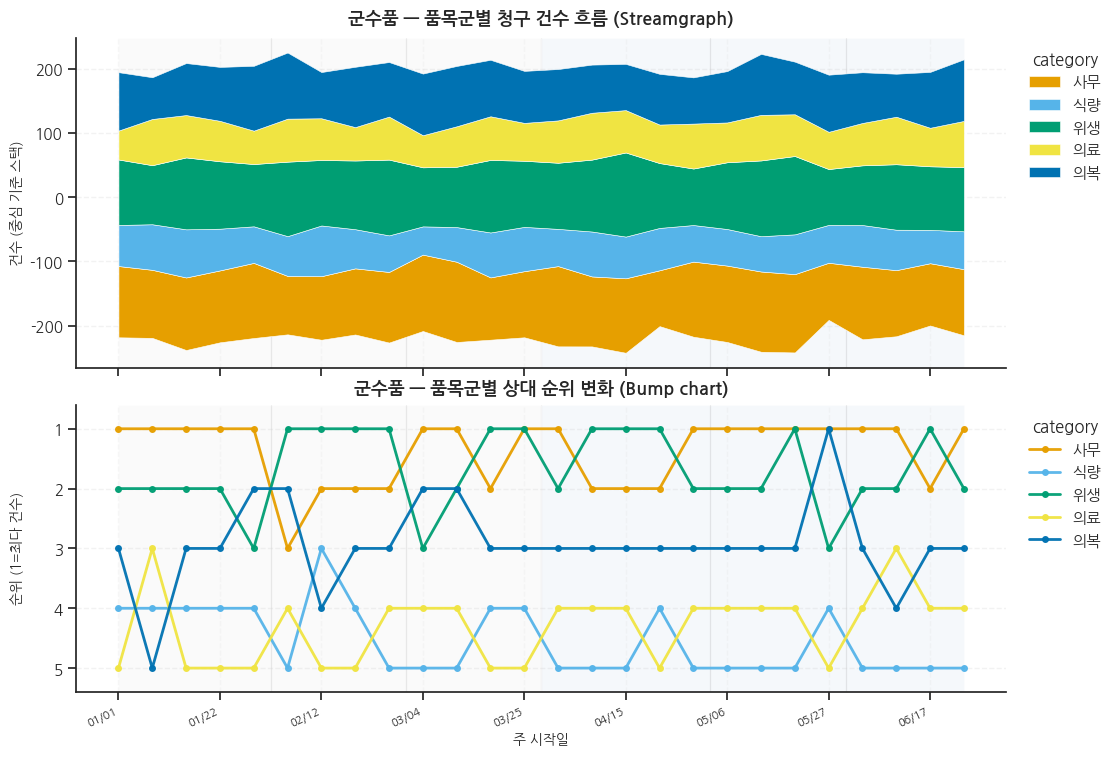

In [21]:
df_s = df_supply.copy()
df_s["_d"] = pd.to_datetime(df_s["request_date"])

# [주간 그룹화] 일요일을 시작으로 하는 주 단위(Period) 생성
df_s["_w"] = df_s["_d"].dt.to_period("W-SUN")

# 주별, 품목군별 청구 건수 집계
counts = (
    df_s.groupby(["_w", "category"], observed=True)
       .size()
       .reset_index(name="n")
)
cats = sorted(df_s["category"].dropna().unique())
COLOR_CAT = stable_cat_colors(df_s["category"])

# 피벗: (행)주, (열)품목군, 값:청구건수, 결측=0
pivot = (
    counts.pivot(index="_w", columns="category", values="n")
          .reindex(columns=cats)
          .fillna(0)
          .sort_index()
)

# 시각화용 기본 데이터
week_starts = pd.PeriodIndex(pivot.index, freq="W-SUN").to_timestamp()  # x축 실제 날짜
x = np.arange(len(pivot))
layers = [pivot[c].values.astype(float) for c in cats]
colors = [COLOR_CAT[c] for c in cats]

# -------------------------------------------------------------------------
# 2. 2행 서브플롯 레이아웃 설정
# -------------------------------------------------------------------------
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(12, 8.5), sharex=True,
    gridspec_kw={"height_ratios": [1.15, 1], "hspace": 0.12}
)

# -------------------------------------------------------------------------
# 3. 시간 흐름 파악을 위한 시각적 보조 장치 (수직선 및 구간 강조)
# -------------------------------------------------------------------------
for i in range(1, len(week_starts)):
    # 월이 바뀌는 지점에 연한 수직선 추가하여 월 경계 구분
    if week_starts[i].month != week_starts[i - 1].month:
        ax_top.axvline(x=i - 0.5, color="#DDDDDD", lw=0.9, zorder=0)
        ax_bot.axvline(x=i - 0.5, color="#DDDDDD", lw=0.9, zorder=0)

# 4월 기준으로 분기/시즌 구분(배경색)
mid_mar = next((i for i, t in enumerate(week_starts) if t.month >= 4), max(1, len(x) // 2))
if 0 < mid_mar < len(x):
    ax_top.axvspan(0, mid_mar - 0.5, facecolor="#F5F5F5", alpha=0.45, zorder=0)
    ax_top.axvspan(mid_mar - 0.5, len(x) - 1, facecolor="#E8EEF5", alpha=0.4, zorder=0)
    ax_bot.axvspan(0, mid_mar - 0.5, facecolor="#F5F5F5", alpha=0.45, zorder=0)
    ax_bot.axvspan(mid_mar - 0.5, len(x) - 1, facecolor="#E8EEF5", alpha=0.4, zorder=0)

# -------------------------------------------------------------------------
# 4. 상단: Streamgraph (청구량의 유동적인 흐름 시각화)
# -------------------------------------------------------------------------
# baseline='wiggle': 연속된 데이터 흐름 강조, 중심축 기준 위아래로
ax_top.stackplot(
    x, layers, labels=cats, colors=colors,
    baseline="wiggle", linewidth=0.4, edgecolor="white"
)
ax_top.set_title("군수품 — 품목군별 청구 건수 흐름 (Streamgraph)", fontsize=13, fontweight="bold", pad=10)
ax_top.set_ylabel("건수 (중심 기준 스택)", fontsize=10)
ax_top.legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False, title="category")
spine_clean(ax_top, grid_y=True)

# -------------------------------------------------------------------------
# 5. 하단: Bump Chart (품목 간 상대적 인기/중요도 순위 변동)
# -------------------------------------------------------------------------
# 주별로 건수순 → 낮은 숫자가 1위
ranks = pivot.rank(axis=1, ascending=False, method="min")
for c in cats:
    ax_bot.plot(
        x, ranks[c].values, marker="o", markersize=4, linewidth=2,
        color=COLOR_CAT[c], label=c, alpha=0.95
    )

ax_bot.set_yticks(range(1, len(cats) + 1))
ax_bot.set_ylim(len(cats) + 0.4, 0.6)
ax_bot.set_ylabel("순위 (1=최다 건수)", fontsize=10)
ax_bot.set_title("군수품 — 품목군별 상대 순위 변화 (Bump chart)", fontsize=13, fontweight="bold", pad=8)
ax_bot.legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False, title="category")
spine_clean(ax_bot, grid_y=True)

# X축: 주 시작일 형식으로 간격 설정
tick_idx = list(range(0, len(x), max(1, len(x) // 8)))
ax_bot.set_xticks([x[i] for i in tick_idx])
ax_bot.set_xticklabels([week_starts[i].strftime("%m/%d") for i in tick_idx], rotation=25, ha="right", fontsize=8)
ax_bot.set_xlabel("주 시작일", fontsize=10)

fig.align_ylabels([ax_top, ax_bot])
plt.tight_layout(rect=[0, 0, 0.80, 1])  # 우측 범례 공간 확보
plt.show()